# Código atualizado


In [30]:
# ============================================
# 0) Imports
# ============================================
import warnings

import numpy as np
import pandas as pd
import numpy as np

# from dataclasses import dataclass
# from typing import Callable, List, Tuple, Dict, Any, Optional
# from datetime import datetime

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# from sklearn.metrics import (
#     accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
#     confusion_matrix, classification_report
# )

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
# from itertools import combinations
# from sklearn.preprocessing import PolynomialFeatures

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


In [31]:
# ============================================
# 1) Carregar datasets
# ============================================
DATASET_HC = 'dataset_voz_completo_HC.csv'
DATASET_PD = 'dataset_voz_completo_PD.csv'

df_HC = pd.read_csv(DATASET_HC)
df_PD = pd.read_csv(DATASET_PD)
print("Shape original HC:", df_HC.shape)
print("Shape original DF:", df_PD.shape)

df_HC['status'] = 0
df_PD['status'] = 1

df_concat = pd.concat([df_HC, df_PD], ignore_index=True)

df_concat.to_csv('dataset_concatenado.csv', index=False)

print("Shape final:", df_concat.shape)
df_concat.head()


Shape original HC: (41, 88)
Shape original DF: (40, 88)
Shape final: (81, 89)


,file_name,group,f0_mean_hz,f0_std_hz,f0_min_hz,f0_max_hz,f0_cv,f1_mean_hz,f1_std_hz,f2_mean_hz,...,spec_flux_mean,spec_flux_std,spec_energy_low_mean,spec_energy_mid_mean,spec_energy_high_mean,tsallis_sq_amp,shannon_s1_amp,tsallis_sq_f0,shannon_s1_f0,status
0,AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav,HC_AH,131.121658,1.382661,127.979975,135.285714,0.010545,670.176352,11.476255,1144.639964,...,0.113668,0.042128,2.135428,12.731040,0.035838,2.175084,3.616453,0.471591,0.543912,0
1,AH_114S_A89F3548-0B61-4770-B800-2E26AB3908B6.wav,HC_AH,110.595296,1.771228,105.192754,115.377726,0.016015,624.156806,50.759496,975.646622,...,0.183278,0.084410,6.280130,4.587857,0.013371,2.150822,3.590799,0.619451,0.727357,0
2,AH_121A_BD5BA248-E807-4CB9-8B53-47E7FFE5F8E2.wav,HC_AH,234.182987,1.199626,231.386563,237.600742,0.005123,475.504882,48.768486,883.969002,...,0.076905,0.025209,34.665394,8.976105,0.020312,2.141979,3.551923,0.000000,-0.000000,0
3,AH_123G_559F0706-2238-447C-BA39-DB5933BA619D.wav,HC_AH,102.822765,0.989926,100.932166,106.161438,0.009628,595.806684,165.885054,1011.652389,...,0.115013,0.034062,16.381947,10.330296,0.079708,2.144335,3.571178,0.000000,-0.000000,0
4,AH_195B_39DA6A45-F4CC-492A-80D4-FB79049ACC22.wav,HC_AH,111.466057,1.052937,109.405717,114.119047,0.009446,698.353948,45.373953,1107.937845,...,0.178199,0.063370,1.263110,4.190388,0.049585,2.157088,3.593633,0.285120,0.352543,0


In [32]:
# ============================================
# 2) Identificar colunas com valores nulos
# ============================================
cols_with_nans = df_concat.columns[df_concat.isnull().any()].tolist()
print(cols_with_nans)

# Configurar e aplicar o Imputador pela Mediana
# A mediana é mais robusta a outliers comuns em sinais de áudio
imputer = SimpleImputer(strategy='median')

# Criamos uma cópia para preservar o dataframe original se necessário
df_imputed = df_concat.copy()

# Aplicamos a transformação apenas nas colunas identificadas
df_imputed[cols_with_nans] = imputer.fit_transform(df_imputed[cols_with_nans])


# 4. Verificação
print(f"Imputação concluída nas colunas: {cols_with_nans}")
print("Total de valores nulos no dataset após o processo:", df_imputed.isnull().sum().sum())

['jitter_local', 'jitter_rap', 'jitter_ppq5', 'tsallis_sq_f0', 'shannon_s1_f0']
Imputação concluída nas colunas: ['jitter_local', 'jitter_rap', 'jitter_ppq5', 'tsallis_sq_f0', 'shannon_s1_f0']
Total de valores nulos no dataset após o processo: 0


In [ ]:
# ------------- SALVANDO O DATASET IMPUTADO :: IMPUTED DATA ---------------------
df_imputed.to_csv('dataset_imputado.csv', index=False)

In [34]:
# ============================================
# 3) Extração do subject_id
# Padrão: AH_064F_UUID.wav -> Extrai '064F'
# ============================================
def extract_subject_id(name):
    parts = str(name).split('_')
    return parts[1] if len(parts) >= 2 else None

df = pd.read_csv('dataset_imputado.csv')
df["subject_id"] = df["file_name"].apply(extract_subject_id)



# checagem rápida
if df["subject_id"].isna().any():
    raise ValueError("Falha ao extrair subject_id de algumas linhas. Verifique o padrão da coluna 'name'.")

print("Nº de sujeitos:", df["subject_id"].nunique())

Nº de sujeitos: 81


In [ ]:
# ------------- ATUALIZANDO O DATASET IMPUTADO :: SUBJECT_ID ---------------------
df.to_csv('dataset_imputado.csv', index=False)

In [40]:
# ============================================
# 4) Preparar X, y e grupos
# Removemos metadados e o target das features
# ============================================

cols_to_drop = ["file_name", "group", "status", "subject_id"]

tsallis_cols = [c for c in df.columns if c.startswith("tsallis")]
feature_cols = [c for c in df.columns if (c not in cols_to_drop) and (c not in tsallis_cols)]


X = df[feature_cols + tsallis_cols]
y = df["status"].astype(int)
groups = df["subject_id"]

print("Colunas tsallis:", tsallis_cols)
print("Colunas a serem descartadas:", cols_to_drop)
print("Colunas de features:", feature_cols + tsallis_cols)
print(len(feature_cols + tsallis_cols), "features selecionadas.")
print("\nBalanceamento (após limpeza):")
print(pd.Series(y).value_counts().rename(index={0: "Controle(0)", 1: "Parkinson(1)"}))

Colunas tsallis: ['tsallis_sq_amp', 'tsallis_sq_f0']
Colunas a serem descartadas: ['file_name', 'group', 'status', 'subject_id']
Colunas de features: ['f0_mean_hz', 'f0_std_hz', 'f0_min_hz', 'f0_max_hz', 'f0_cv', 'f1_mean_hz', 'f1_std_hz', 'f2_mean_hz', 'f2_std_hz', 'f3_mean_hz', 'f3_std_hz', 'f4_mean_hz', 'f4_std_hz', 'hnr_mean_db', 'jitter_local', 'jitter_rap', 'jitter_ppq5', 'shimmer_local', 'shimmer_apq3', 'shimmer_apq5', 'shimmer_apq11', 'mfcc1_mean', 'mfcc1_std', 'dmfcc1_mean', 'dmfcc1_std', 'mfcc2_mean', 'mfcc2_std', 'dmfcc2_mean', 'dmfcc2_std', 'mfcc3_mean', 'mfcc3_std', 'dmfcc3_mean', 'dmfcc3_std', 'mfcc4_mean', 'mfcc4_std', 'dmfcc4_mean', 'dmfcc4_std', 'mfcc5_mean', 'mfcc5_std', 'dmfcc5_mean', 'dmfcc5_std', 'mfcc6_mean', 'mfcc6_std', 'dmfcc6_mean', 'dmfcc6_std', 'mfcc7_mean', 'mfcc7_std', 'dmfcc7_mean', 'dmfcc7_std', 'mfcc8_mean', 'mfcc8_std', 'dmfcc8_mean', 'dmfcc8_std', 'mfcc9_mean', 'mfcc9_std', 'dmfcc9_mean', 'dmfcc9_std', 'mfcc10_mean', 'mfcc10_std', 'dmfcc10_mean', 'dmf

In [41]:
# ============================================
# 5) Split Treino/Teste SEM leakage (por sujeito) 80/20
#    (apenas cria os índices; não treina nada aqui)
# ============================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# verificando a integridade
train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])
intersection = train_subjects.intersection(test_subjects)

print(f"Sujeitos no Treino: {len(train_subjects)} | Teste: {len(test_subjects)}")
print(f"Leakage check (deve ser 0): {len(intersection)} interseções encontradas.")
if len(intersection) != 0:
    raise ValueError("Houve leakage: mesmos sujeitos em treino e teste.")

Sujeitos no Treino: 64 | Teste: 17
Leakage check (deve ser 0): 0 interseções encontradas.


In [42]:
# ============================================
# 6) QuantileClipper
# ============================================
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, low=0.01, high=0.99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        # Calcula os limites (quantis) para cada coluna
        self.lo_ = np.nanquantile(X, self.low, axis=0)
        self.hi_ = np.nanquantile(X, self.high, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        # Aplica o limitador: valores abaixo de lo_ viram lo_ 
        # e acima de hi_ viram hi_
        return np.clip(X, self.lo_, self.hi_)

Top correlações mais altas:
jitter_rap      jitter_local      0.997734
shannon_s1_f0   tsallis_sq_f0     0.992662
f0_cv           f0_std_hz         0.985925
shimmer_apq3    shimmer_local     0.984866
shannon_s1_amp  tsallis_sq_amp    0.981985
                                    ...   
dmfcc4_std      mfcc2_std         0.702677
dmfcc9_std      dmfcc4_std        0.701425
mfcc11_std      dmfcc4_std        0.700969
mfcc13_std      mfcc11_std        0.699812
dmfcc9_std      dmfcc5_std        0.699087
Length: 86, dtype: float64


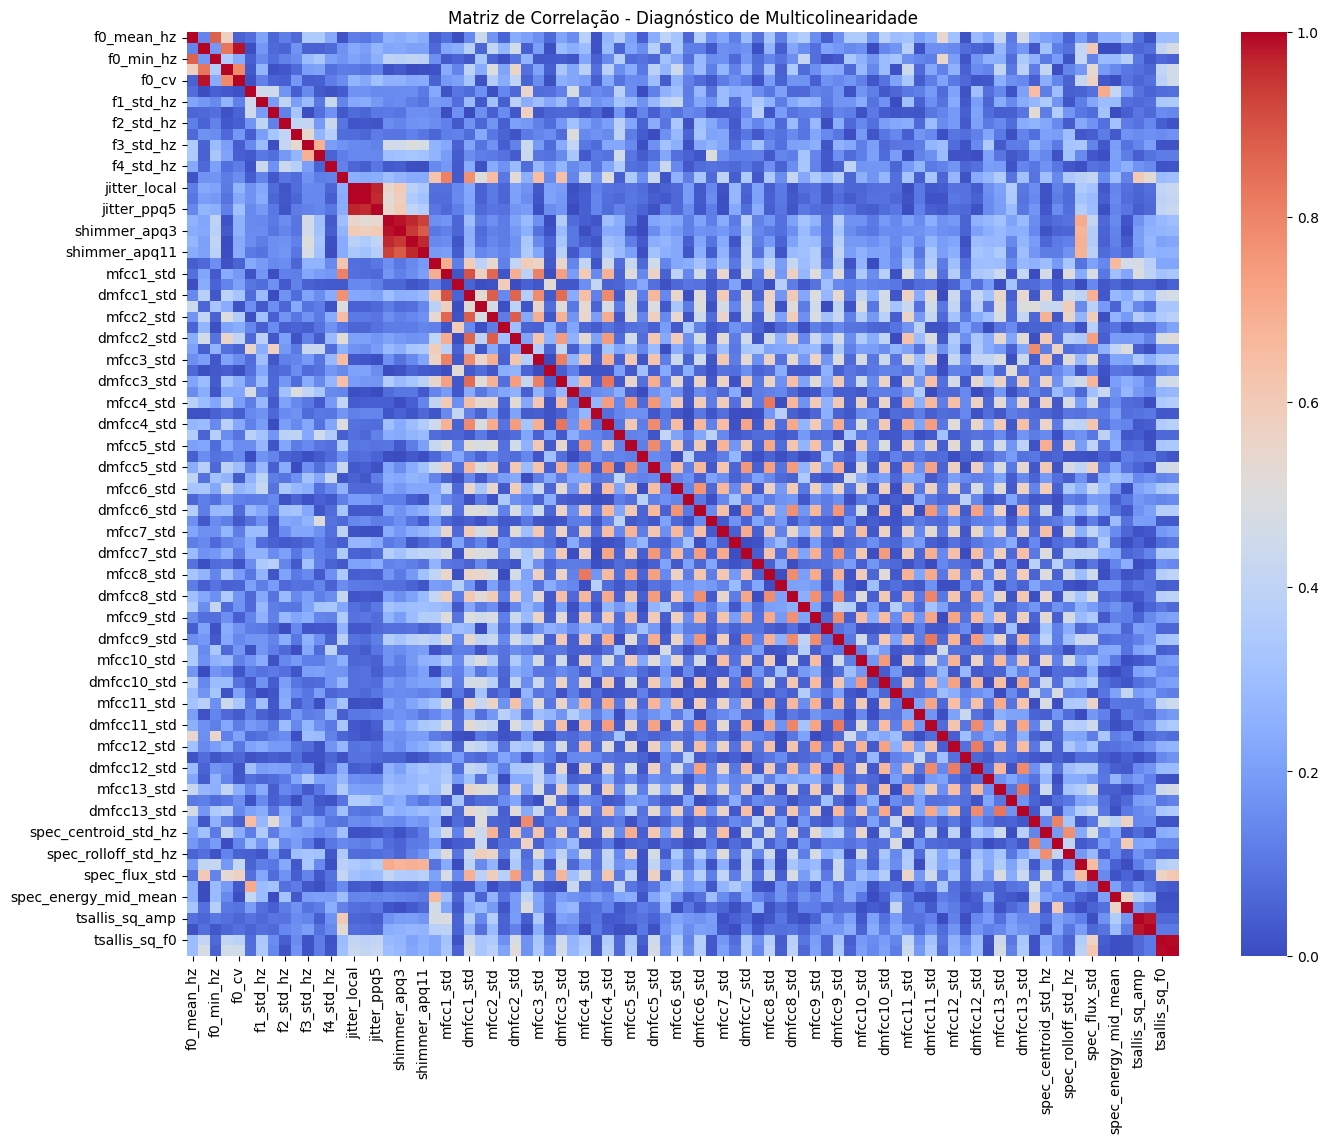


Número de colunas com correlação > 0.85: 12
Colunas altamente correlacionadas (> 0.85): ['f0_min_hz', 'f0_cv', 'jitter_rap', 'jitter_ppq5', 'shimmer_apq3', 'shimmer_apq5', 'shimmer_apq11', 'dmfcc1_std', 'mfcc2_std', 'dmfcc2_std', 'shannon_s1_amp', 'shannon_s1_f0']


In [51]:
# ============================================
# 7) analise de multicolinearidade
# ============================================

CORRELATION_THRESHOLD = 0.85

# Carregar o dataset imputado
df_analise = pd.read_csv('dataset_imputado.csv')

# Remover colunas não numéricas para o cálculo de correlação
cols_to_exclude = ['file_name', 'group', 'status', 'subject_id']
df_numeric = df_analise.drop(columns=[col for col in cols_to_exclude if col in df.columns])

# Calcular a matriz de correlação (Pearson)
corr_matrix = df_numeric.corr().abs()

# Selecionar o triângulo superior da matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variáveis com correlação superior a 0.8
highly_correlated = [column for column in upper.columns if any(upper[column] > CORRELATION_THRESHOLD)]

# Preparar dados para visualização (top correlações)
unstacked_corr = upper.unstack().dropna()
sorted_corr = unstacked_corr.sort_values(ascending=False)

# Mostrar as maiores correlações
print("Top correlações mais altas:")
print(sorted_corr.head(86))

# Plotar um Heatmap das correlações
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Matriz de Correlação - Diagnóstico de Multicolinearidade")
plt.savefig('correlation_heatmap.png')
plt.show()

# Contagem de colunas problemáticas
print(f"\nNúmero de colunas com correlação > {CORRELATION_THRESHOLD}: {len(highly_correlated)}")
print(f"Colunas altamente correlacionadas (> {CORRELATION_THRESHOLD}): {highly_correlated}")


In [9]:
# # ============================================
# # 7) analise de multicolinearidade
# # ============================================

# # 1. Selecionar apenas as colunas de características (X)
# cols_to_exclude = ['file_name', 'group', 'status', 'subject_id']
# feature_cols = [c for c in df_imputed.columns if c not in cols_to_exclude]
# X_temp = df_imputed[feature_cols]

# # 2. Cálculo iterativo para remover r > 0.9
# corr_matrix = X_temp.corr().abs()
# dropped_cols = []
# temp_corr = corr_matrix.copy()

# while True:
#     # Identifica o triângulo superior da matriz de correlação
#     upper = temp_corr.where(np.triu(np.ones(temp_corr.shape), k=1).astype(bool))
    
#     # Encontra pares que violam o limite de 0.9
#     pairs = [(column, row) for column in upper.columns for row in upper.index if upper.loc[row, column] > 0.9]
    
#     if not pairs:
#         break # Sai do loop quando não houver mais correlações altas
    
#     # Lista colunas envolvidas em conflitos
#     confliting_cols = list(set([col for pair in pairs for col in pair]))
    
#     # Decide remover a coluna com a maior correlação média entre as conflitantes
#     mean_corr = temp_corr.loc[confliting_cols, confliting_cols].mean()
#     col_to_drop = mean_corr.idxmax()
    
#     dropped_cols.append(col_to_drop)
#     temp_corr = temp_corr.drop(index=col_to_drop, columns=col_to_drop)

# # 3. Aplicar a remoção no dataframe original
# df_cleaned = df_imputed.drop(columns=dropped_cols)
# df_cleaned.to_csv('dataset_cleaned.csv', index=False)

# print(f"Colunas removidas por redundância (r > 0.9): {len(dropped_cols)}")
# print(f"Colunas descartadas: {dropped_cols}")

In [52]:
# ============================================
# 8) Função: consenso de features
# ============================================
def get_consensus_features(rf_imp, xgb_imp, cat_imp, top_k=16):
    """Combine rankings of the 3 models to obtain consensus on the best features"""

    rf_ranked = rf_imp.reset_index(drop=True)
    xgb_ranked = xgb_imp.reset_index(drop=True)
    cat_ranked = cat_imp.reset_index(drop=True)

    rf_rank_dict = {row['feature']: idx + 1 for idx, row in rf_ranked.iterrows()}
    xgb_rank_dict = {row['feature']: idx + 1 for idx, row in xgb_ranked.iterrows()}
    cat_rank_dict = {row['feature']: idx + 1 for idx, row in cat_ranked.iterrows()}

    all_features = set(rf_rank_dict.keys()) | set(xgb_rank_dict.keys()) | set(cat_rank_dict.keys())

    consensus_ranking = {}
    for feature in all_features:
        rf_pos = rf_rank_dict.get(feature, len(rf_ranked) + 1)
        xgb_pos = xgb_rank_dict.get(feature, len(xgb_ranked) + 1)
        cat_pos = cat_rank_dict.get(feature, len(cat_ranked) + 1)
        consensus_ranking[feature] = (rf_pos + xgb_pos + cat_pos) / 3

    sorted_features = sorted(consensus_ranking.items(), key=lambda x: x[1])
    return [feature for feature, _ in sorted_features[:top_k]]


In [53]:
# Pré-processamento comum
preprocess = ImbPipeline(steps=[
    ("clip", QuantileClipper(0.01, 0.99)),
    ("scale", RobustScaler())
])

X_proc = preprocess.fit_transform(X)


In [58]:

# recarregando dataset para evitar confusão com as colunas removidas por multicolinearidade
df_imputed = pd.read_csv('dataset_imputado.csv')
cols_to_exclude = ['file_name', 'group', 'status','subject_id']
feature_cols = [c for c in df_imputed.columns if c not in cols_to_exclude]
df = df_imputed.drop(columns=cols_to_exclude)

print(f'df.shape: {df.shape}')
df.head()  


df.shape: (81, 86)


,f0_mean_hz,f0_std_hz,f0_min_hz,f0_max_hz,f0_cv,f1_mean_hz,f1_std_hz,f2_mean_hz,f2_std_hz,f3_mean_hz,...,spec_rolloff_std_hz,spec_flux_mean,spec_flux_std,spec_energy_low_mean,spec_energy_mid_mean,spec_energy_high_mean,tsallis_sq_amp,shannon_s1_amp,tsallis_sq_f0,shannon_s1_f0
0,131.121658,1.382661,127.979975,135.285714,0.010545,670.176352,11.476255,1144.639964,63.341984,1330.132101,...,57.503658,0.113668,0.042128,2.135428,12.731040,0.035838,2.175084,3.616453,0.471591,0.543912
1,110.595296,1.771228,105.192754,115.377726,0.016015,624.156806,50.759496,975.646622,141.790388,1440.038270,...,119.018714,0.183278,0.084410,6.280130,4.587857,0.013371,2.150822,3.590799,0.619451,0.727357
2,234.182987,1.199626,231.386563,237.600742,0.005123,475.504882,48.768486,883.969002,33.684506,1356.054512,...,108.766394,0.076905,0.025209,34.665394,8.976105,0.020312,2.141979,3.551923,0.000000,-0.000000
3,102.822765,0.989926,100.932166,106.161438,0.009628,595.806684,165.885054,1011.652389,246.124451,1713.858459,...,71.863709,0.115013,0.034062,16.381947,10.330296,0.079708,2.144335,3.571178,0.000000,-0.000000
4,111.466057,1.052937,109.405717,114.119047,0.009446,698.353948,45.373953,1107.937845,117.293316,1331.432769,...,283.711987,0.178199,0.063370,1.263110,4.190388,0.049585,2.157088,3.593633,0.285120,0.352543


In [ ]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_proc, y)

rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)


# XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_proc, y)
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)


# CatBoost
cat = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=False,
    random_seed=42
)
cat.fit(X_proc, y)
cat_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": cat.get_feature_importance()
}).sort_values("importance", ascending=False)

In [62]:
# Seleciona 16 features principais
top_features = get_consensus_features(
    rf_imp=rf_importance,
    xgb_imp=xgb_importance,
    cat_imp=cat_importance,
    top_k=16
)

print("Top 16 features por consenso:")
for f in top_features:
    print("-", f)

Top 16 features por consenso:
- mfcc11_std
- mfcc13_std
- mfcc9_std
- mfcc10_std
- mfcc8_std
- mfcc3_std
- mfcc1_std
- dmfcc3_mean
- dmfcc6_std
- shimmer_local
- mfcc1_mean
- spec_rolloff_std_hz
- dmfcc13_std
- shimmer_apq3
- spec_flux_mean
- dmfcc7_std


In [15]:
# ============================================
# 9) Definir as features selecionadas (Top-16)
# ============================================
selected_features = [
    "mfcc13_std", 
    "mfcc11_std",
    "mfcc2_mean",
    "shimmer_local",
    "dmfcc6_std",
    "dmfcc13_std",
    "mfcc10_std", 
    "mfcc3_std", 
    "mfcc1_std",
    "dmfcc3_mean",
    "dmfcc13_mean",
    "mfcc9_std",
    "dmfcc10_std",
    "mfcc1_mean",
    "dmfcc7_std",
    "spec_centroid_mean_hz",    
]

# selected_features = [
#     "mfcc11_std",
#     "mfcc13_std", 
#     "mfcc1_std", 
#     "mfcc10_std", 
#     "dmfcc3_mean",
#     "dmfcc13_std",
#     "tsallis_sq_amp",
#     "mfcc9_std",
#     "shimmer_local",
#     "mfcc8_std",
#     "mfcc12_std",
#     "spec_rolloff_std_hz",
#     "mfcc1_mean",
#     "dmfcc13_mean",
#     "dmfcc7_std",
#     "shimmer_apq3",
# ]

missing = set(selected_features) - set(df.columns)
if missing:
    raise ValueError(f"Colunas selecionadas não encontradas no dataset: {missing}")


In [16]:
# ============================================
# 10) Criar dataset reduzido (features + status + subject_id)
# ============================================
df = pd.read_csv('dataset_imputado.csv')  # Recarrega para garantir que temos todas as colunas  
df_reduced = df[selected_features + ["status", "subject_id"]].copy()
print("\nShape dataset reduzido:", df_reduced.shape)



Shape dataset reduzido: (81, 18)


In [17]:
# ============================================
# 11) Salvar datasets (limpo e reduzido)
# ============================================
reduced_path = "dataset_reduced_top16.csv"

df_reduced.to_csv(reduced_path, index=False)

print("\nArquivos salvos:")
print("-", reduced_path)


Arquivos salvos:
- dataset_reduced_top16.csv


In [18]:
df_tsallis = pd.read_csv('dataset_reduced_top16.csv')  # Carrega dataset reduzido (para criar novo dataset com tsallis)  
df_imputed = pd.read_csv('dataset_imputado.csv')  # Recarrega dataset com todas as colunas para copiar as colunas tsallis para o novo dataset

df_tsallis = pd.concat([df_tsallis, df_imputed.filter(like="tsallis")], axis=1)
df_tsallis.to_csv('dataset_tsallis.csv', index=False)


In [19]:
def make_pipeline(model):
    return ImbPipeline(steps=[
        # 1. Imputação: Garante que não haja nulos entrando nos transformadores
        ("imputer", SimpleImputer(strategy='median')),

        # 2. Clipping: Amortece os outliers extremos antes do escalonamento
        ("clip", QuantileClipper(0.01, 0.99)),
        
        # 3. RobustScaler: Escalonamento robusto baseado em quartis
        ("scale", RobustScaler()),

        # 4. SMOTE: Balanceamento sintético aplicado apenas durante o 'fit' (treino)
        ("smote", SMOTE(random_state=42, k_neighbors=3)),

        # 5. O Classificador (SVC, XGBoost, etc.)
        ("clf", model)
    ])
    

In [20]:
# =========================================================
# 13) Benchmark: roda GroupKFold CV e devolve tabela resumo
# =========================================================
def benchmark_models(X, y, groups, models_dict, n_splits=5, n_jobs=1):
    cv = GroupKFold(n_splits=n_splits)

    scoring = {
        "bal_acc": "balanced_accuracy",
        "roc_auc": "roc_auc",
        "f1": "f1",
    }

    rows = []
    for name, model in models_dict.items():
        pipe = make_pipeline(model)

        scores = cross_validate(
            pipe, X, y,
            groups=groups,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            error_score="raise"
        )

        rows.append({
            "model": name,
            "bal_acc_mean": float(np.mean(scores["test_bal_acc"])),
            "bal_acc_std":  float(np.std(scores["test_bal_acc"])),
            "roc_auc_mean": float(np.mean(scores["test_roc_auc"])),
            "roc_auc_std":  float(np.std(scores["test_roc_auc"])),
            "f1_mean":      float(np.mean(scores["test_f1"])),
            "f1_std":       float(np.std(scores["test_f1"])),
        })

    return pd.DataFrame(rows).sort_values("bal_acc_mean", ascending=False).reset_index(drop=True)


In [21]:
# =========================================================
# 14) Carregar dataset para benchmarking
#    Escolha UM:
#    A) dataset reduzido Top-16 (recomendado pelo tamanho do dataset)
#    B) dataset completo limpo 
# =========================================================

USE_REDUCED = True  # mude para False se quiser testar com dataset completo

if USE_REDUCED:
    df = pd.read_csv("dataset_reduced_top16.csv")
    feature_cols = [c for c in df.columns if c not in ["status", "subject_id"]]
else:
    df = pd.read_csv("/dataset_cleaned.csv")
    feature_cols = [c for c in df.columns if c not in ["name", "status", "subject_id"]]

X = df[feature_cols].values
y = df["status"].astype(int).values
groups = df["subject_id"].values

print("Dataset usado:", "REDUZIDO Top-16" if USE_REDUCED else "COMPLETO (limpo)")
print("Shape:", df.shape)
print("Nº features:", len(feature_cols))
print("Nº sujeitos:", df["subject_id"].nunique())
print("Balanceamento:", pd.Series(y).value_counts().to_dict())

Dataset usado: REDUZIDO Top-16
Shape: (81, 18)
Nº features: 16
Nº sujeitos: 81
Balanceamento: {0: 41, 1: 40}


In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
# =========================================================
# 15) Modelos (SEM CatBoost)
# =========================================================
RNG_SEED = 42

models = {
    "logreg_l2": LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=RNG_SEED,
            fit_intercept=True,
        ),
    "svc_rbf":  SVC(
            C=100.0,
            gamma=0.1,
            kernel="rbf",
            probability=False,          # necessário para ROC-AUC via predict_proba
            class_weight="balanced",
            random_state=RNG_SEED,      # usado na calibração interna do probability=True
        ),
    # LinearSVC não tem predict_proba -> calibramos para ter probabilidade para ROC-AUC
    "linear_svc_cal": CalibratedClassifierCV(
            estimator=LinearSVC(
                C=1.0,
                class_weight="balanced",
                random_state=RNG_SEED,
                max_iter=10000,
            ),
            method="sigmoid",
            cv=3,
        ),
    # -------------------------
    # Árvores / Ensembles
    # -------------------------
    "random_forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced",
            random_state=RNG_SEED,
            n_jobs=-1,
        ),
    "gradient_boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=1.0,
            random_state=RNG_SEED,
        ),
    "adaboost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=1.0,            
            random_state=RNG_SEED,
        ),
    "decision_tree": DecisionTreeClassifier(
            criterion="gini",
            max_depth=5,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=RNG_SEED,
        ),
    # -------------------------
    # KNN (não tem random_state)
    # -------------------------
    "knn": KNeighborsClassifier(
            n_neighbors=7,
            weights="distance",
            metric="minkowski",
            p=2,
        ),
    
    # -------------------------
    # MLP (rede rasa)
    # -------------------------
    "mlp": MLPClassifier(
            hidden_layer_sizes=(50, 50),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate="constant",
            learning_rate_init=0.001,
            max_iter=2000,
            tol=1e-5,
            early_stopping=False,
            random_state=RNG_SEED,
        ),
    # -------------------------
    # XGBoost / CatBoost
    # -------------------------
    "xgboost": XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1.0,
            reg_lambda=1.0,
            reg_alpha=0.0,
            gamma=0.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RNG_SEED,
            n_jobs=-1,
            verbosity=0,
        ),

}


In [23]:
# =========================================================
# 16) Rodar benchmark (GroupKFold por sujeito)
# =========================================================
results = benchmark_models(X, y, groups, models, n_splits=5, n_jobs=1)

# Mostrar ranking
print("\n=== Ranking por Balanced Accuracy (GroupKFold, sem leakage) ===")
print(results)


=== Ranking por Balanced Accuracy (GroupKFold, sem leakage) ===
               model  bal_acc_mean  bal_acc_std  roc_auc_mean  roc_auc_std  \
0           adaboost      0.738889     0.071981      0.814236     0.067436   
1      random_forest      0.738889     0.100212      0.811111     0.061776   
2                knn      0.738889     0.100212      0.825694     0.075056   
3          logreg_l2      0.713889     0.084414      0.810417     0.083177   
4            xgboost      0.713889     0.101246      0.789931     0.079521   
5                mlp      0.677778     0.103059      0.776042     0.069253   
6     linear_svc_cal      0.676389     0.047222      0.789583     0.112895   
7  gradient_boosting      0.654167     0.062639      0.729688     0.095248   
8            svc_rbf      0.640278     0.042446      0.700694     0.047069   
9      decision_tree      0.595833     0.070465      0.595833     0.070465   

    f1_mean    f1_std  
0  0.724571  0.084888  
1  0.739286  0.081001  
2  0